### Task 1.1 : DataSet Summary 

In [1]:
import pandas as pd

df = pd.read_csv("Dataset1.csv")

df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [2]:
print("Shape :",df.shape)
print("Rows:",df.shape[0])
print("Colomns:",df.shape[1])

Shape : (186074, 12)
Rows: 186074
Colomns: 12


In [3]:
print(df.columns)

Index(['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL',
       'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time',
       'Distance'],
      dtype='object')


In [4]:
print("Unique Trains:",df["Train_No"].nunique())
print("Unique Station:",df["Station_Name"].unique())

Unique Trains: 11113
Unique Station: ['SAWANTWADI R' 'THIVIM' 'KARMALI' ... 'AMBALA CANT JN' 'LUDHIANA JN'
 'SHMATA VD KATRA']


In [5]:
df.head(15)

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0
5,2,108,KRMI,265,232,199,166,KARMALI,1,21:04:00,21:06:00,33
6,3,108,THVM,355,304,253,202,THIVIM,1,21:26:00,21:28:00,51
7,4,108,SWV,515,432,349,266,SAWANTWADI R,1,22:25:00,00:00:00,83
8,1,128,MAO,100,100,100,100,MADGOAN JN.,1,19:40:00,19:40:00,0
9,2,128,KRMI,265,232,199,166,KARMALI,1,20:18:00,20:20:00,33


### Task 1.2 - Train-wisw Start & End Station

In [6]:
df = df.sort_values(["Train_No","Distance"])

route_tabel = df.groupby("Train_No").agg(
    Start_Station = ("Station_Name", "first"),
    End_Station = ("Station_Name", "last")
).reset_index()

print(route_tabel.head())

   Train_No Start_Station   End_Station
0       107  SAWANTWADI R   MADGOAN JN.
1       108   MADGOAN JN.  SAWANTWADI R
2       128   MADGOAN JN.   CHHATRAPATI
3       290  DELHI-SAFDAR  DELHI-SAFDAR
4       401    AURANGABAD  VARANASI JN.


### Task 1.3 - Basic Statistics

In [7]:
print(df["Distance"].describe())

count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64


### Task 1.4 - Missing Values

In [8]:
print("Missing Values:",df.isnull().sum().sum())

print("Duplicate Rows:",df.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


### Level 1 Conclusion
#### - Dataset Contain 186074 records and 12 colummns
#### - Train-wise routes were identified using minimum distance.
#### - Distance and number of stops were summarized using descriptive statistics.
#### - Missing values and duplicate records were checked to assess data quality.

## Level 2 - Data Cleaning & Feature Engineering

### Task 2.1 - Hadle Missing Values

In [9]:
print(df.isnull().sum())

df.ffill(inplace=True)

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


In [10]:
print("Duplicate Rows Before:",df.duplicated().sum())

df = df.drop_duplicates()

print("Duplicate Rows After :",df.duplicated().sum())

Duplicate Rows Before: 0
Duplicate Rows After : 0


### Task 2.2 - Standardize Arrival & Deparature Time

In [11]:
import pandas as pd 

df["Arrival_time"] = pd.to_datetime(
    df["Arrival_time"],format = "%H:%M:%S"
)

df["Departure_Time"] = pd.to_datetime(
    df["Departure_Time"],format="%H:%M:%S"
)

print(df[["Arrival_time", "Departure_Time"]].head())

         Arrival_time      Departure_Time
0 1900-01-01 00:00:00 1900-01-01 10:25:00
1 1900-01-01 11:06:00 1900-01-01 11:08:00
2 1900-01-01 11:28:00 1900-01-01 11:30:00
3 1900-01-01 12:10:00 1900-01-01 00:00:00
4 1900-01-01 00:00:00 1900-01-01 20:30:00


### TAsk 2.3 - Calculate Journey Duration

In [12]:
df["Journey_Duration_Min"]=(
    df["Departure_Time"] - df["Arrival_time"]
).dt.total_seconds() / 60

df.loc[df["Journey_Duration_Min"] < 0, "Journey_Duration_Min"] += 24 * 60 

print(df[["Arrival_time", "Departure_Time","Journey_Duration_Min"]].head(10))

         Arrival_time      Departure_Time  Journey_Duration_Min
0 1900-01-01 00:00:00 1900-01-01 10:25:00                 625.0
1 1900-01-01 11:06:00 1900-01-01 11:08:00                   2.0
2 1900-01-01 11:28:00 1900-01-01 11:30:00                   2.0
3 1900-01-01 12:10:00 1900-01-01 00:00:00                 710.0
4 1900-01-01 00:00:00 1900-01-01 20:30:00                1230.0
5 1900-01-01 21:04:00 1900-01-01 21:06:00                   2.0
6 1900-01-01 21:26:00 1900-01-01 21:28:00                   2.0
7 1900-01-01 22:25:00 1900-01-01 00:00:00                  95.0
8 1900-01-01 19:40:00 1900-01-01 19:40:00                   0.0
9 1900-01-01 20:18:00 1900-01-01 20:20:00                   2.0


## Level 2 Conclusion

#### - The dataset was cleaned by checking for missing values and duplicate records.
#### - Time-related columns were converted into a standardized datetime format.
#### - Journey duration was computed for each train journey.
#### - New features, including **Total Distance** and **Number of Stops**, were generated to improve data analysis and model performance.
#### - The processed dataset is now prepared for further exploration, visualization, and predictive modeling.

## Task 3.1: Compare Journey Duration Across Different Routes

#### The journey duration of each train was calculated using the departure time of the starting station and the arrival time of the final station. 
#### This allows comparison of journey duration across different train routes.

In [13]:
df = df.sort_values(["Train_No", "Distance"])

route_duration = df.groupby("Train_No").agg(
    Start_Station =("Station_Name", "first"),
    End_Station = ("Station_Name", "last"),
    Departure_Time = ("Departure_Time", "first"),
    Arrival_time = ("Arrival_time", "last"),
    Total_Distance = ("Distance", "max"),
    Number_of_Stops = ("Station_Name", "count")
).reset_index()

route_duration["Journey_Duration_Min"]=(
    route_duration["Arrival_time"]-
    route_duration["Departure_Time"]
).dt.total_seconds()/60

route_duration.loc[
    route_duration["Journey_Duration_Min"]<0,
    "Journey_Duration_Min"
] += 24 * 60

route_duration[
    [
        "Train_No",
        "Start_Station",
        "End_Station",
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration_Min"
    ]
].head(10)

,Train_No,Start_Station,End_Station,Total_Distance,Number_of_Stops,Journey_Duration_Min
0,107,SAWANTWADI R,MADGOAN JN.,78,4,105.0
1,108,MADGOAN JN.,SAWANTWADI R,83,4,115.0
2,128,MADGOAN JN.,CHHATRAPATI,978,22,1325.0
3,290,DELHI-SAFDAR,DELHI-SAFDAR,2694,14,480.0
4,401,AURANGABAD,VARANASI JN.,1618,12,750.0
5,421,LUCKNOW JN.,SHRI MATA VA,1276,5,540.0
6,422,SHRI MATA VA,LUCKNOW JN.,1277,5,165.0
7,477,SIRSA,SIRSA,2616,14,190.0
8,502,RAJENDRANAGA,AMBALA CANTT,1206,9,1380.0
9,504,PATNA JN.,BATHINDA JN,1313,3,60.0


In [14]:
route_duration["Journey_Duration_Min"].describe()

count    11113.000000
mean       276.013498
std        321.166943
min          0.000000
25%         61.000000
50%        132.000000
75%        365.000000
max       1435.000000
Name: Journey_Duration_Min, dtype: float64

In [15]:
route_duration.sort_values(
    "Journey_Duration_Min",
    ascending = False
).head(10)

,Train_No,Start_Station,End_Station,Departure_Time,Arrival_time,Total_Distance,Number_of_Stops,Journey_Duration_Min
374,11103,JHANSI JN,BANDRA TERMI,1900-01-01 16:50:00,1900-01-01 16:45:00,1321,21,1435.0
1723,15001,MUZAFFARPUR,DEHRA DUN,1900-01-01 14:00:00,1900-01-01 13:55:00,1122,26,1435.0
1300,12949,PORBANDAR,SANTRAGACHI,1900-01-01 08:10:00,1900-01-01 08:05:00,2664,37,1435.0
888,12494,HAZRAT NIZAM,PUNE JN.,1900-01-01 21:35:00,1900-01-01 21:25:00,1501,10,1430.0
1140,12778,KOCHUVELI,HUBLI JN.,1900-01-01 12:50:00,1900-01-01 12:40:00,1297,22,1430.0
252,8617,RANCHI,ANAND VIHAR,1900-01-01 14:05:00,1900-01-01 13:55:00,1365,15,1430.0
1128,12766,AMRAVATI,TIRUPATI,1900-01-01 06:45:00,1900-01-01 06:35:00,1305,24,1430.0
406,11404,CHHATRAPATI,NAGPUR JN.(C,1900-01-01 12:50:00,1900-01-01 12:35:00,1026,22,1425.0
1139,12777,HUBLI JN.,KOCHUVELI,1900-01-01 06:45:00,1900-01-01 06:30:00,1295,22,1425.0
2074,16534,KRANTIVIRA S,BHAGAT-KI-KO,1900-01-01 17:00:00,1900-01-01 16:45:00,2161,30,1425.0


In [16]:
route_duration[
    route_duration["Journey_Duration_Min"] >= 1000
][
    [
        "Train_No",
        "Start_Station",
        "End_Station",
        "Departure_Time",
        "Arrival_time",
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration_Min"
    ]
].head(20)

,Train_No,Start_Station,End_Station,Departure_Time,Arrival_time,Total_Distance,Number_of_Stops,Journey_Duration_Min
2,128,MADGOAN JN.,CHHATRAPATI,1900-01-01 19:40:00,1900-01-01 17:45:00,978,22,1325.0
8,502,RAJENDRANAGA,AMBALA CANTT,1900-01-01 10:30:00,1900-01-01 09:30:00,1206,9,1380.0
21,1301,PUNE JN.,MANGALORE JN,1900-01-01 18:50:00,1900-01-01 12:30:00,976,17,1060.0
22,1302,MANGALORE JN,PUNE JN.,1900-01-01 15:45:00,1900-01-01 13:10:00,973,17,1285.0
24,1655,PUNE JN.,JABALPUR,1900-01-01 10:45:00,1900-01-01 06:15:00,1050,13,1170.0
25,1656,JABALPUR,PUNE JN.,1900-01-01 19:30:00,1900-01-01 14:05:00,1050,13,1115.0
26,1705,BANDRA TERMI,JABALPUR,1900-01-01 00:15:00,1900-01-01 21:40:00,1261,14,1285.0
27,1706,JABALPUR,BANDRA TERMI,1900-01-01 14:20:00,1900-01-01 11:15:00,1262,14,1255.0
32,2191,JABALPUR,SANTRAGACHI,1900-01-01 20:10:00,1900-01-01 16:00:00,1123,16,1190.0
33,2192,SANTRAGACHI,JABALPUR,1900-01-01 20:40:00,1900-01-01 15:50:00,1123,16,1150.0


In [17]:
route_duration[
    [
        "Train_No",
        "Start_Station",
        "End_Station",
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration_Min"
    ]
    ].sort_values(
        "Journey_Duration_Min",
        ascending = False
    ).head(10)

,Train_No,Start_Station,End_Station,Total_Distance,Number_of_Stops,Journey_Duration_Min
374,11103,JHANSI JN,BANDRA TERMI,1321,21,1435.0
1723,15001,MUZAFFARPUR,DEHRA DUN,1122,26,1435.0
1300,12949,PORBANDAR,SANTRAGACHI,2664,37,1435.0
888,12494,HAZRAT NIZAM,PUNE JN.,1501,10,1430.0
1140,12778,KOCHUVELI,HUBLI JN.,1297,22,1430.0
252,8617,RANCHI,ANAND VIHAR,1365,15,1430.0
1128,12766,AMRAVATI,TIRUPATI,1305,24,1430.0
406,11404,CHHATRAPATI,NAGPUR JN.(C,1026,22,1425.0
1139,12777,HUBLI JN.,KOCHUVELI,1295,22,1425.0
2074,16534,KRANTIVIRA S,BHAGAT-KI-KO,2161,30,1425.0


## Task 3.1 Conclusion

#### - Journey duration was calculated for each train using the departure time of the starting station and arrival time of the final station.
#### - The dataset contains 11,113 train routes for the calculated journey-duration analysis.
#### - The average journey duration was 276.01 minutes, while the median journey duration was 132 minutes.
#### - The maximum calculated journey duration was 1,435 minutes (23 hours 55 minutes).
#### - Trains 11103, 15001, and 12949 recorded the highest calculated journey duration.
#### - Some records showed very low or zero journey duration despite having large travel distances, indicating limitations in the available time data.
#### - Overall, journey duration varies considerably across different train routes.

In [18]:
station_traffic = (
    df.groupby("Station_Name")
    .size()
    .reset_index(name="Train_Count")
    .sort_values("Train_Count", ascending=False)
)

print("Top 10 Busiest Stations:")
station_traffic.head(10)

Top 10 Busiest Stations:


,Station_Name,Train_Count
1755,CST-MUMBAI,1027
3466,KALYAN JN,828
7509,THANE,796
6834,SEALDAH,745
1592,CHENNAI BEAC,738
2950,HOWRAH JN.,699
1773,DADAR,598
2213,DUM DUM JN.,463
4245,KURLA,462
7401,TAMBARAM,434


In [19]:
print("Top 10 Least Busy Stations:")
station_traffic.sort_values(
    "Train_Count",
    ascending = True
).head(10)

Top 10 Least Busy Stations:


,Station_Name,Train_Count
4287,LADDIVADI,1
6820,SATYAVALLI,1
4504,MADIMANGALAM,1
1725,CHOTIPADOLI,1
146,AMAR SAHEED,1
3637,KARIGANURU,1
3627,KARCHIYA YAR,1
7863,VANGAICHUNGP,1
4454,LUDHIANA JN,1
7480,TENERI HALT,1


## Task 3.2 Conclusion

#### - Station-wise train traffic was analyzed by counting the number of train records associated with each station.
#### - CST-MUMBAI was identified as the busiest station in the dataset with 1,027 train records.
#### - KALYAN JN and THANE were the next highest-traffic stations with 828 and 796 train records respectively.
#### - Several stations in the lowest-traffic group appeared only once in the dataset.
#### - The analysis shows significant variation in train traffic across different stations.

In [20]:
correlation = route_duration[
    ["Total_Distance", "Journey_Duration_Min"]
    ].corr()

print("Correlation Matrix:")
print(correlation)

Correlation Matrix:
                      Total_Distance  Journey_Duration_Min
Total_Distance                1.0000                0.6357
Journey_Duration_Min          0.6357                1.0000


In [21]:
correlation_value = route_duration["Total_Distance"].corr(
    route_duration["Journey_Duration_Min"]

)

print(
    "Correlation between Distance and Journey Duration :",
    round(correlation_value, 4)

)

Correlation between Distance and Journey Duration : 0.6357


## task 3.3 Conclusion 

#### - The correlation between Total Distance and Journey Duration was **0.6357**.
#### - This indicates a moderate positive relationship between distance and journey duration.
#### - In general, longer train routes tend to require longer journey durations.
#### - However, the relationship is not perfectly linear, indicating that other factors may also influence journey duration.

In [22]:
print("========EDA SUMMARY========")

print("Total Unique Trains:",
      df["Train_No"].nunique())

print("Total Unique Station:",
      df["Station_Name"].nunique())

print("Average Journey Duration:",
      round(route_duration["Journey_Duration_Min"].mean(),2),
      "minutes")

print("Midian Journey Duration:",
      round(route_duration["Journey_Duration_Min"].median(),2),
      "minutes")

print("Average Total Distance :",
      round(route_duration["Total_Distance"].mean(),2),
      "km")

print("Maximum Journey Duration :",
      route_duration["Journey_Duration_Min"].max(),
      "minutes")

print("Maximum Distance:",
      route_duration["Total_Distance"].max(),
      "km")

print("Distance-Journey Duration correlation:",
      round(
          route_duration["Total_Distance"].corr(
              route_duration["Journey_Duration_Min"]
          ), 4

      ))
     

========EDA SUMMARY========
Total Unique Trains: 11113
Total Unique Station: 8099
Average Journey Duration: 276.01 minutes
Midian Journey Duration: 132.0 minutes
Average Total Distance : 348.87 km
Maximum Journey Duration : 1435.0 minutes
Maximum Distance: 4260 km
Distance-Journey Duration correlation: 0.6357


## Task 3.4 Conclusion:

#### - The dataset contains **11,113 unique trains** and **8,099 unique stations**.
#### - The average journey duration was **276.01 minutes**, while the median journey duration was **132 minutes**.
#### - The average total distance covered by trains was **348.87 km**.
#### - The maximum calculated journey duration was **1,435 minutes**.
#### - The maximum recorded train route distance was **4,260 km**.
#### - A correlation of **0.6357** was observed between total distance and journey duration, indicating a moderate positive relationship.
#### - Overall, the exploratory analysis shows considerable variation in train routes, station traffic, distance, and journey duration.

## Level 3 Conclusion:

#### - Train-wise journey durations were analyzed to compare different routes.
#### - Station traffic analysis identified high-traffic and low-traffic stations.
#### - The relationship between distance and journey duration showed a moderate positive correlation of **0.6357**.
#### - The dataset contains **11,113 unique trains** and **8,099 unique stations**, providing substantial variation for exploratory analysis.
#### - Overall, the analysis highlights important patterns in train routes, station traffic, distance, and journey duration.

## LEvel 4 : Visualization & Pattern Analysis :

## Task 4.1 : Visualization & Pattern Analysis

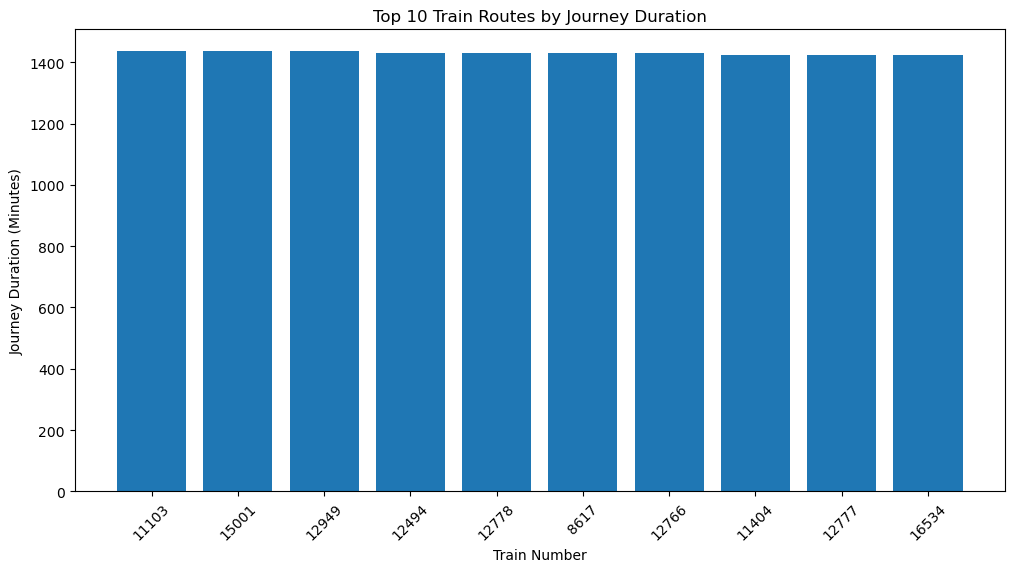

In [23]:
import matplotlib.pyplot as plt

top_routes = route_duration.sort_values(
    "Journey_Duration_Min",
    ascending = False
).head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_routes["Train_No"].astype(str),
    top_routes["Journey_Duration_Min"]
)

plt.xlabel("Train Number")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Top 10 Train Routes by Journey Duration")
plt.xticks(rotation=45)

plt.show()

## Task 4.1 Conclusion:

#### - The bar chart visualizes the top 10 train routes based on calculated journey duration.
#### - Trains 11103, 15001, and 12949 have the highest journey duration of 1,435 minutes.
#### - The remaining trains in the top 10 have journey durations between 1,425 and 1,430 minutes.
#### - The visualization makes it easy to compare journey durations across different train routes.

## Task 4.2 : Visualize Station-Wise Train Traffic 

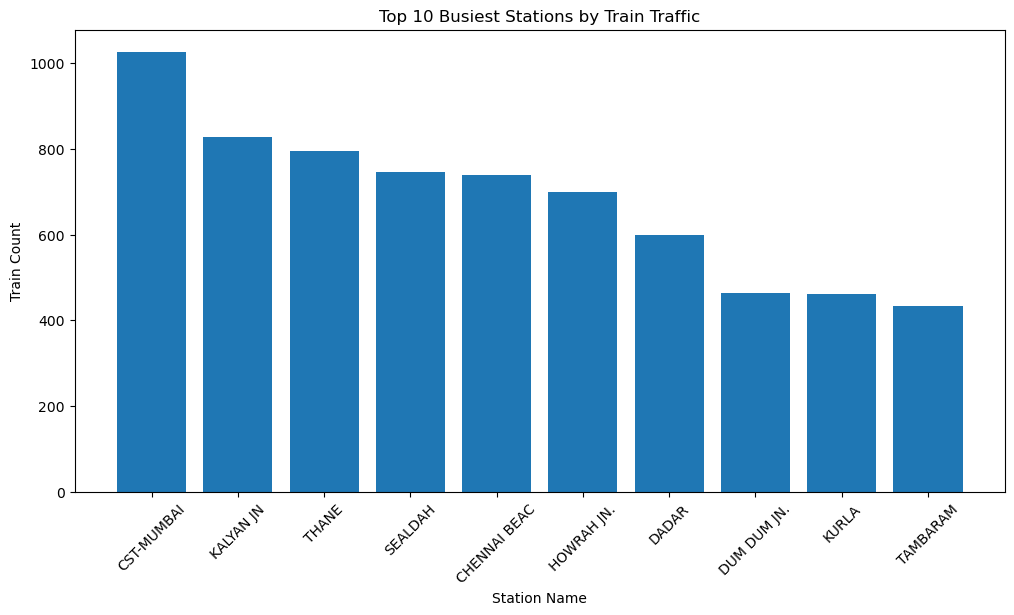

In [24]:
top_stations = station_traffic.head(10)

plt.figure(figsize=(12, 6))

plt.bar(
    top_stations["Station_Name"],
    top_stations["Train_Count"]
)

plt.xlabel("Station Name")
plt.ylabel("Train Count")
plt.title("Top 10 Busiest Stations by Train Traffic")
plt.xticks(rotation=45)

plt.show()

## Task 4.2 Conclusion:

#### - The bar chart shows the top 10 busiest stations based on train traffic.
#### - CST-MUMBAI has the highest train traffic with 1,027 train records.
#### - KALYAN JN and THANE follow with 828 and 796 train records respectively.
#### - The visualization clearly shows that train traffic varies considerably across stations.
#### - The chart provides an easy comparison of the busiest stations in the dataset.

## Task 4.3 : Distance Vs Journey Duration

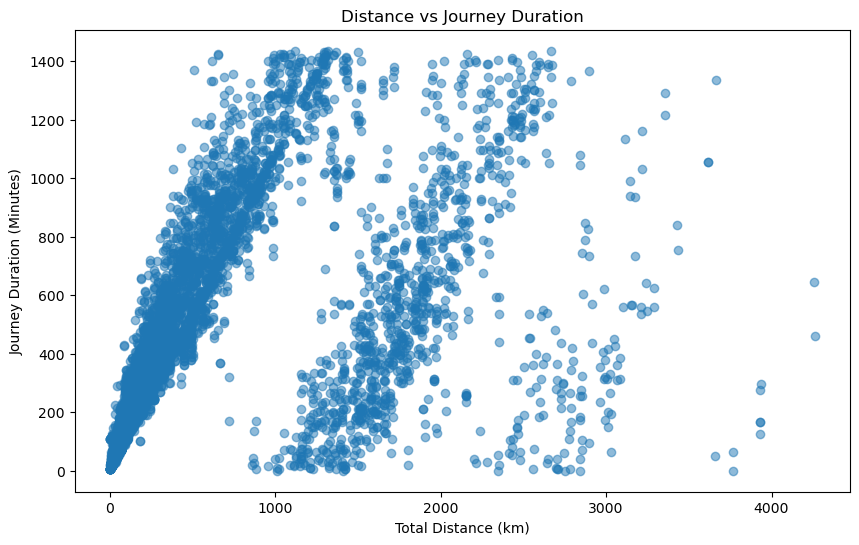

In [25]:
plt.figure(figsize=(10, 6))

plt.scatter(
    route_duration["Total_Distance"],
    route_duration["Journey_Duration_Min"],
    alpha = 0.5
)

plt.xlabel("Total Distance (km)")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Distance vs Journey Duration")

plt.show()

## Task 4.3 Conclusion :

#### - The scatter plot shows the relationship between total distance and journey duration.
#### - The points show an overall positive pattern, indicating that longer-distance routes generally tend to have longer journey durations.
#### - The relationship is not perfectly linear because journey duration can vary considerably for routes with similar distances.
#### - This visual pattern is consistent with the calculated correlation coefficient of **0.6357**, which indicates a moderate positive relationship.

## Task 4.4 : Visual Pattern And Insights

#### - The journey-duration bar chart shows that the top train routes have calculated journey durations close to the maximum value of 1,435 minutes.
#### - The station traffic chart shows that CST-MUMBAI has the highest train traffic, followed by KALYAN JN and THANE.
#### - The station-wise visualization shows considerable variation in train traffic across different stations.
#### - The distance versus journey-duration scatter plot shows an overall positive relationship between the two variables.
#### - The scatter plot also shows considerable variation, indicating that distance alone does not completely determine journey duration.
#### - The visualizations provide a clear understanding of route duration, station traffic, and the relationship between distance and journey duration.

## Level 4 Conclusion :

#### - Visualizations were used to analyze journey duration, station-wise train traffic, and the relationship between distance and journey duration.
#### - The journey-duration chart identified trains with the highest calculated durations.
#### - The station traffic chart identified CST-MUMBAI as the busiest station in the dataset.
#### - The distance versus journey-duration plot showed an overall positive relationship, consistent with the correlation value of 0.6357.
#### - Overall, the visual analysis helped identify important patterns and variations in train routes and station traffic.

## 5 : Prediction Model Development 

In [26]:
model_data = route_duration[
    [
        "Total_Distance",
        "Number_of_Stops",
        "Journey_Duration_Min"

    ]
    ].copy()

model_data = model_data.dropna()

x = model_data[
    [
        "Total_Distance",
        "Number_of_Stops"
    ]
    ]
y = model_data["Journey_Duration_Min"]

print("Modeling Dataset Shape:",model_data.shape)

print("\nFeatures:")
print(x.head())

print("\nTarget:")
print(y.head())

Modeling Dataset Shape: (11113, 3)

Features:
   Total_Distance  Number_of_Stops
0              78                4
1              83                4
2             978               22
3            2694               14
4            1618               12

Target:
0     105.0
1     115.0
2    1325.0
3     480.0
4     750.0
Name: Journey_Duration_Min, dtype: float64


## 5.1 Conclusion :

#### - A modeling dataset containing **11,113 records** was prepared.
#### - **Total_Distance** and **Number_of_Stops** were selected as input features.
#### - **Journey_Duration_Min** was selected as the target variable.
#### - Missing values were removed before preparing the dataset.
#### - The prepared dataset is ready for train-test splitting and model development.

In [27]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42
)

print("Training Feature Shape :", x_train.shape)
print("Testing Features Shape :", x_test.shape)
print("Training Target Shape :", y_train.shape)
print("TestingT arget Shape :",  y_test.shape)

Training Feature Shape : (8890, 2)
Testing Features Shape : (2223, 2)
Training Target Shape : (8890,)
TestingT arget Shape : (2223,)


## Task 5.2 Conclusion:

#### - The modeling dataset was divided into training and testing sets using an 80:20 split.
#### - The training set contains **8,890 records**.
#### - The testing set contains **2,223 records**.
#### - Two input features, Total_Distance and Number_of_Stops, were retained for model training.
#### - The testing set will be used to evaluate the Linear Regression model.

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

y_pred = model.predict(x_test)

print("Linear Regression Model Trained Successfully.")

print("\nModel Coefficient:")
print(model.coef_)

print("\nModel Itercept:")
print(model.intercept_)

print("\nFirst 10 Prediction:")
print(y_pred[:10])

Linear Regression Model Trained Successfully.

Model Coefficient:
[0.27463452 6.61181464]

Model Itercept:
68.5662148813202

First 10 Prediction:
[368.70712897 262.12835    195.54327945 129.65859509 246.74881703
  94.99288723 292.48926408  92.50059034 707.3520751  526.25142439]


## Task 5.3 Conclusion

#### - A Linear Regression model was successfully trained to predict train journey duration.
#### - Total Distance and Number of Stops were used as the input features.
#### - The coefficient for Total Distance was **0.2746**.
#### - The coefficient for Number of Stops was **6.6118**.
#### - The model successfully generated predicted journey durations for the test dataset.
#### - These predictions will be evaluated using MAE and RMSE in the next task.

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Mean Absolute Error (MAE):",round(mae, 2))
print("Root Main Squared Error (RMSE):",round(rmse, 2))

Mean Absolute Error (MAE): 152.21
Root Main Squared Error (RMSE): 237.39


## Task 5.4 Conclusion :

#### - The Linear Regression model was evaluated using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).
#### - The model achieved an **MAE of 152.21 minutes**.
#### - The model achieved an **RMSE of 237.39 minutes**.
#### - The MAE indicates that the model's predictions differ from the actual journey durations by approximately 152.21 minutes on average.
#### - The RMSE is higher than the MAE, indicating that some predictions have relatively larger errors.
#### - These results provide a baseline evaluation of the Linear Regression model for predicting train journey duration.

## Level 5 Final Conclusion:

#### - A machine learning dataset was prepared using **Total Distance** and **Number of Stops** as input features.
#### - The dataset was divided into **8,890 training records** and **2,223 testing records**.
#### - A Linear Regression model was successfully developed to predict train journey duration.
#### - The model achieved an **MAE of 152.21 minutes** and an **RMSE of 237.39 minutes**.
#### - The results provide a baseline for predicting journey duration using distance and number of stops.

Actual vs Predicted Journey Duration:
   Actual_Duration  Predicted_Duration
0            690.0          368.707129
1            180.0          262.128350
2             55.0          195.543279
3            190.0          129.658595
4            113.0          246.748817
5             38.0           94.992887
6            450.0          292.489264
7             59.0           92.500590
8            705.0          707.352075
9           1185.0          526.251424


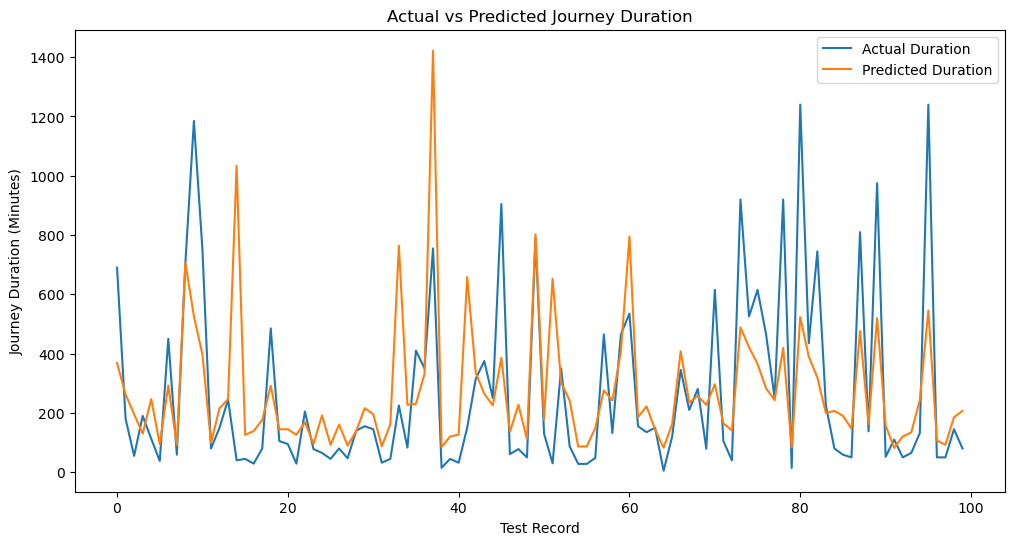

In [34]:
prediction_results = pd.DataFrame({
    "Actual_Duration": y_test.values,
    "Predicted_Duration": y_pred
})

prediction_results = prediction_results.reset_index(drop=True)

print("Actual vs Predicted Journey Duration:")
print(prediction_results.head(10))

plt.figure(figsize=(12,6))

plt.plot(
    prediction_results.index[:100],
    prediction_results["Actual_Duration"][:100],
    label="Actual Duration"
)

plt.plot(
    prediction_results.index[:100],
    prediction_results["Predicted_Duration"][:100],
    label="Predicted Duration"

)
plt.xlabel("Test Record")
plt.ylabel("Journey Duration (Minutes)")
plt.title("Actual vs Predicted Journey Duration")
plt.legend()

plt.show()

## Task 6.1 Conclusion:

#### - A complete journey time prediction system was developed using Linear Regression.
#### - Total Distance and Number of Stops were used to predict journey duration.
#### - The model generated predicted journey durations for the test dataset.
#### - The actual and predicted journey durations were visualized using a line chart.
#### - The visualization shows that the predicted values generally follow the overall pattern of the actual journey durations.
#### - Some differences between actual and predicted values are visible, which is consistent with the MAE of 152.21 minutes and RMSE of 237.39 minutes obtained during model evaluation.
#### - The system demonstrates an end-to-end workflow from data preparation and model training to prediction and visualization.

# Final Project Conclusion 

#### - The train journey dataset was successfully analyzed and prepared for machine learning.
#### - Data cleaning, route analysis, station traffic analysis, and exploratory data analysis were performed.
#### - Visualizations were created to understand journey duration, station traffic, and the relationship between distance and journey duration.
#### - A Linear Regression model was developed using Total Distance and Number of Stops to predict journey duration.
#### - The model was evaluated using MAE and RMSE, achieving an MAE of **152.21 minutes** and an RMSE of **237.39 minutes**.
#### - An end-to-end journey time prediction system was developed.
#### - Actual and predicted journey durations were visualized to assess the model's prediction behavior.
#### - Overall, the project demonstrates the complete data science workflow from data understanding and analysis to predictive modeling and visualization.